# Prac 08.1

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [133]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

C:\Users\misha\AppData\Local\Temp\ipykernel_2684\3037193244.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


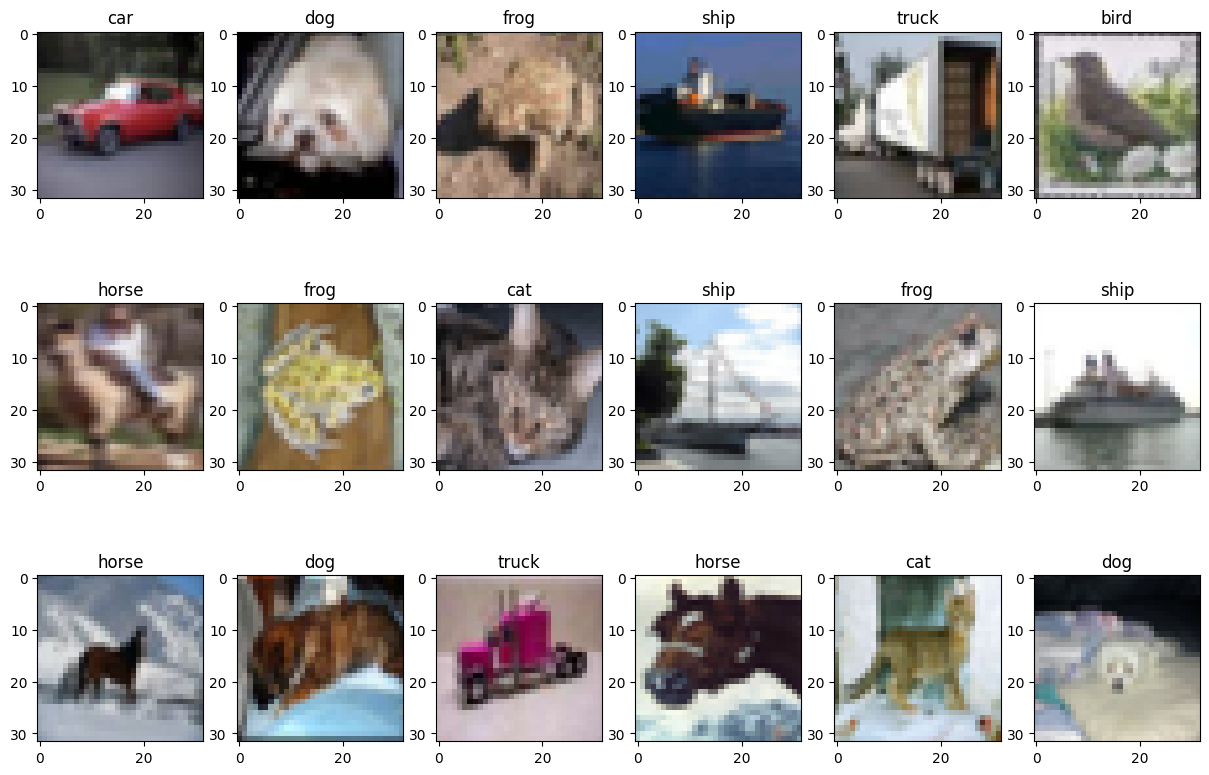

In [134]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = int(np.random.random()*len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

<BarContainer object of 10 artists>

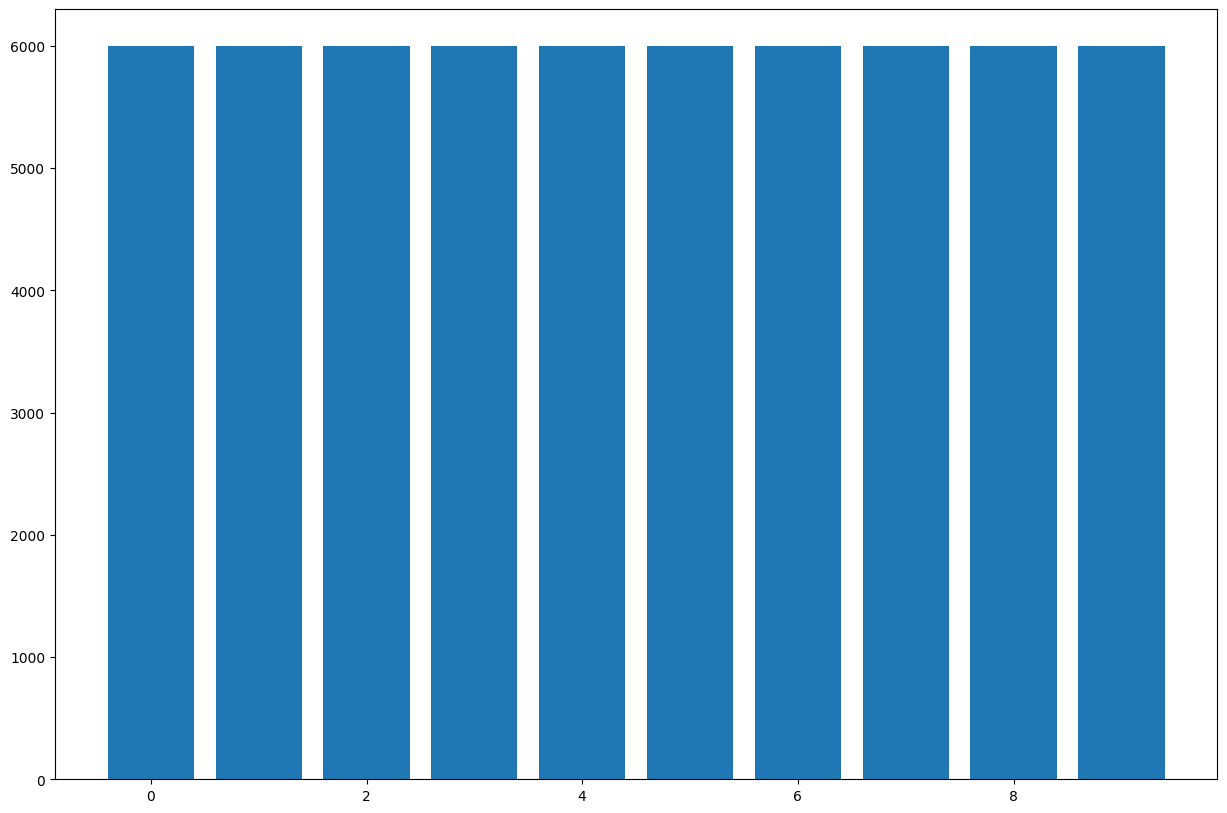

In [135]:
# Compute the class histogram
counts = np.unique(y_train, return_counts=True)[1] + np.unique(y_test, return_counts=True)[1]
plt.bar(range(10), counts)

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [136]:
# Normalization
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-hot encoding
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

y_train = tf.one_hot(y_train, num_classes)
y_test = tf.one_hot(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [137]:
# Build the classifier
inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

# Show the model
model.summary()

Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_28 (Conv2D)          (None, 30, 30, 16)        448       
                                                                 
 max_pooling2d_28 (MaxPoolin  (None, 15, 15, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_29 (Conv2D)          (None, 13, 13, 32)        4640      
                                                                 
 max_pooling2d_29 (MaxPoolin  (None, 6, 6, 32)         0         
 g2D)                                                            
                                                                 
 flatten_14 (Flatten)        (None, 1152)              0  

### Step 3: Training

Compile the model and train it.

In [138]:
epochs = 100
batch_size = 128

# Compile the model
optimizer = Adam(learning_rate = 0.001)
model.compile(loss="categorical_crossentropy", optimizer = optimizer, metrics=["accuracy"])

# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True)
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks=[early_stopping])

Epoch 1/100
352/352 [==============================] - 1s 3ms/step - loss: 1.7168 - accuracy: 0.3881 - val_loss: 1.5583 - val_accuracy: 0.4596
Epoch 2/100
352/352 [==============================] - 1s 3ms/step - loss: 1.3920 - accuracy: 0.5142 - val_loss: 1.3108 - val_accuracy: 0.5426
Epoch 3/100
352/352 [==============================] - 1s 3ms/step - loss: 1.2746 - accuracy: 0.5587 - val_loss: 1.2230 - val_accuracy: 0.5732
Epoch 4/100
352/352 [==============================] - 1s 3ms/step - loss: 1.1953 - accuracy: 0.5867 - val_loss: 1.1626 - val_accuracy: 0.5980
Epoch 5/100
352/352 [==============================] - 1s 3ms/step - loss: 1.1467 - accuracy: 0.6065 - val_loss: 1.1350 - val_accuracy: 0.6064
Epoch 6/100
352/352 [==============================] - 1s 3ms/step - loss: 1.1032 - accuracy: 0.6189 - val_loss: 1.0761 - val_accuracy: 0.6294
Epoch 7/100
352/352 [==============================] - 1s 3ms/step - loss: 1.0693 - accuracy: 0.6336 - val_loss: 1.0870 - val_accuracy: 0.6224

Train Acc      0.7171111106872559
Validation Acc 0.6764000058174133


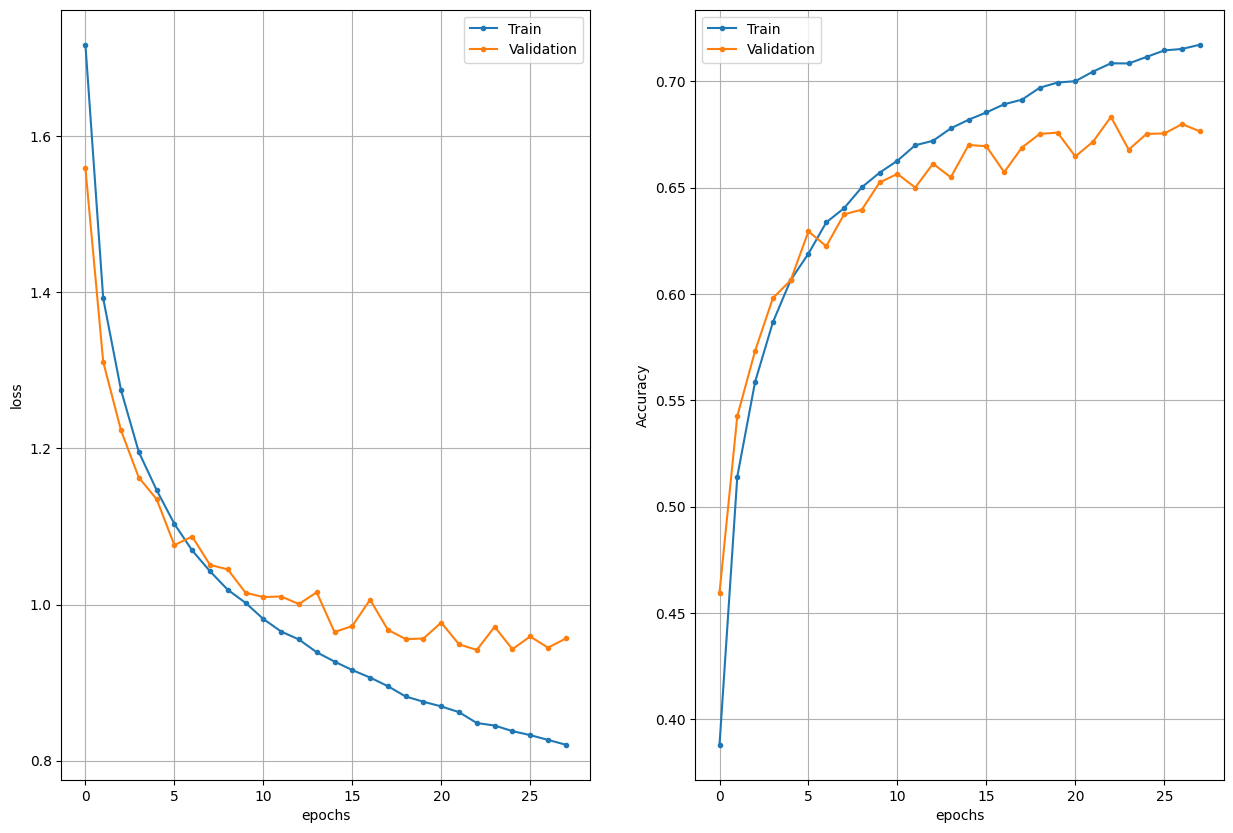

In [139]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [140]:
# Compute the labels and the predictions as sparse values
y_true = tf.argmax(y_test, axis=1).numpy()
y_pred = model.predict(x_test)
y_pred = tf.argmax(y_pred, axis=1).numpy()

313/313 [==============================] - 0s 863us/step


In [141]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    idx = (y_true == class_id)
    acc = (y_pred[idx] == class_id).mean() if idx.any() else 0.0
    print(f"{class_name}: {acc:.4f}")

plane: 0.7730
car: 0.7780
bird: 0.5050
cat: 0.4540
deer: 0.5820
dog: 0.5980
frog: 0.7790
horse: 0.7120
ship: 0.7160
truck: 0.7550


In [142]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 [==============================] - 0s 1ms/step - loss: 0.9807 - accuracy: 0.6652
Test loss   0.9806807637214661
Test metric 0.6651999950408936


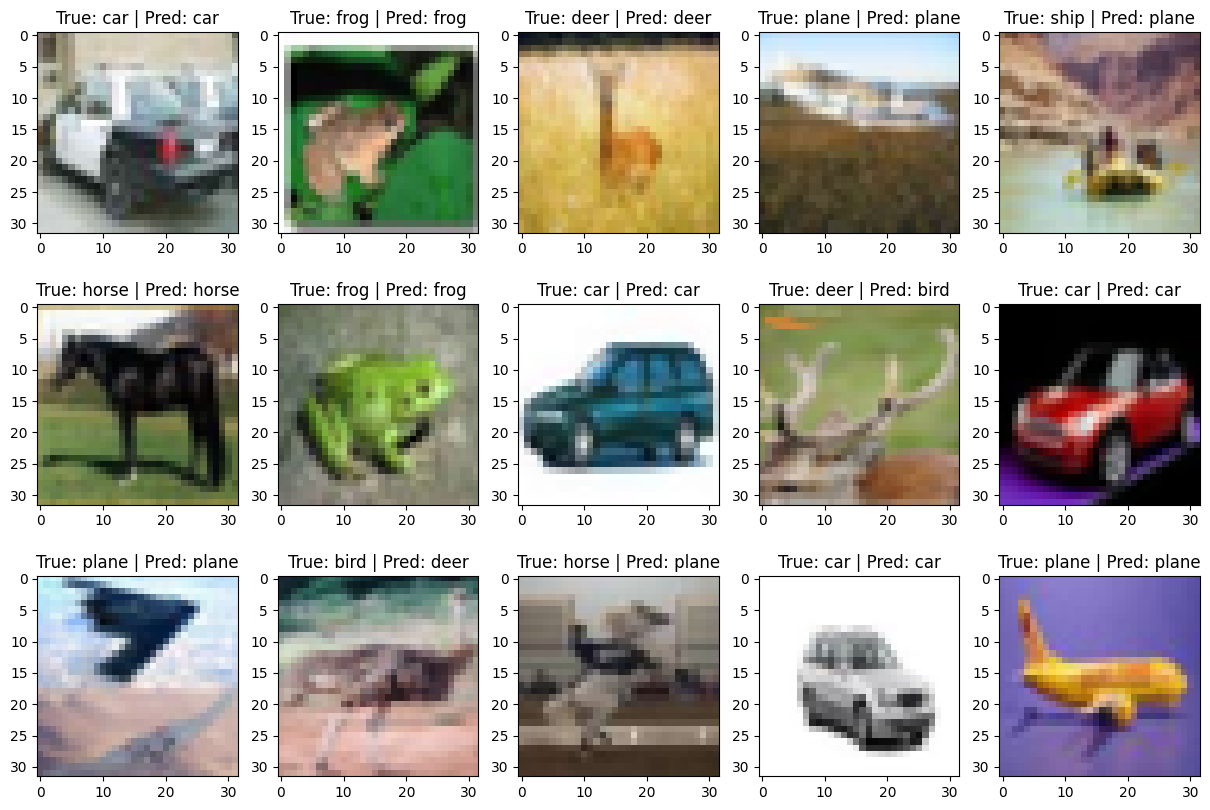

In [143]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = int(np.random.random()*len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

### Questions
* What is the overall accuracy of the classifier? -- 66%
* What modifications would you do in order to improve the classification accuracy? -- Додання шарів згортки, Dense та Dropout перед Dense.
* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

In [144]:
# Build the classifier
inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
net = Dense(64, activation="relu")(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

# Show the model
model.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_30 (Conv2D)          (None, 30, 30, 16)        448       
                                                                 
 max_pooling2d_30 (MaxPoolin  (None, 15, 15, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_31 (Conv2D)          (None, 13, 13, 32)        4640      
                                                                 
 max_pooling2d_31 (MaxPoolin  (None, 6, 6, 32)         0         
 g2D)                                                            
                                                                 
 flatten_15 (Flatten)        (None, 1152)              0  

In [145]:
epochs = 100
batch_size = 128

# Compile the model
optimizer = Adam(learning_rate = 0.001)
model.compile(loss="categorical_crossentropy", optimizer = optimizer, metrics=["accuracy"])

# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True)
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks=[early_stopping])

Epoch 1/100
352/352 [==============================] - 2s 4ms/step - loss: 1.7139 - accuracy: 0.3866 - val_loss: 1.5652 - val_accuracy: 0.4568
Epoch 2/100
352/352 [==============================] - 1s 3ms/step - loss: 1.3744 - accuracy: 0.5119 - val_loss: 1.3348 - val_accuracy: 0.5232
Epoch 3/100
352/352 [==============================] - 1s 3ms/step - loss: 1.2550 - accuracy: 0.5566 - val_loss: 1.2258 - val_accuracy: 0.5676
Epoch 4/100
352/352 [==============================] - 1s 3ms/step - loss: 1.1661 - accuracy: 0.5905 - val_loss: 1.1421 - val_accuracy: 0.6012
Epoch 5/100
352/352 [==============================] - 1s 3ms/step - loss: 1.1080 - accuracy: 0.6133 - val_loss: 1.0803 - val_accuracy: 0.6240
Epoch 6/100
352/352 [==============================] - 1s 3ms/step - loss: 1.0703 - accuracy: 0.6251 - val_loss: 1.0537 - val_accuracy: 0.6392
Epoch 7/100
352/352 [==============================] - 1s 3ms/step - loss: 1.0223 - accuracy: 0.6422 - val_loss: 1.0832 - val_accuracy: 0.6228

Train Acc      0.7718444466590881
Validation Acc 0.6886000037193298


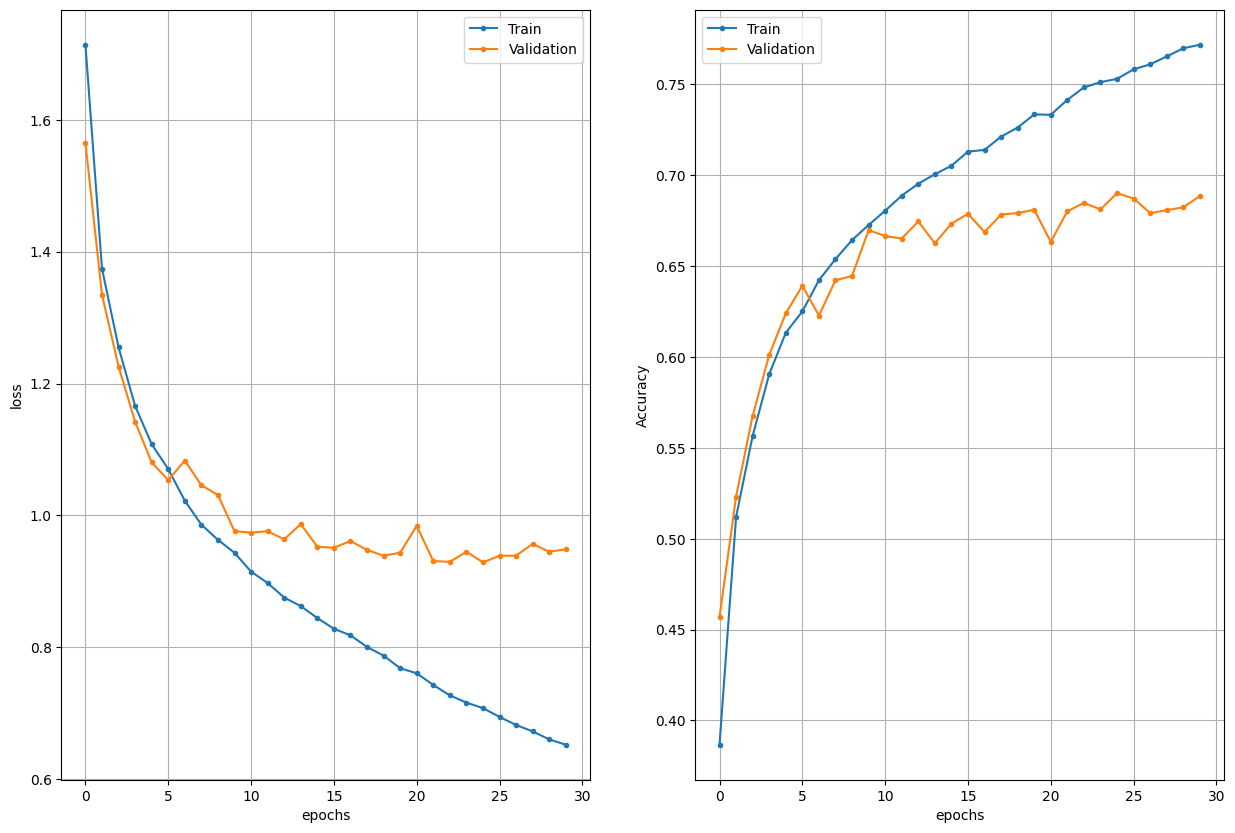

In [146]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [147]:
# Compute the labels and the predictions as sparse values
y_true = tf.argmax(y_test, axis=1).numpy()
y_pred = model.predict(x_test)
y_pred = tf.argmax(y_pred, axis=1).numpy()

# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    idx = (y_true == class_id)
    acc = (y_pred[idx] == class_id).mean() if idx.any() else 0.0
    print(f"{class_name}: {acc:.4f}")

313/313 [==============================] - 0s 1ms/step
plane: 0.7520
car: 0.7760
bird: 0.5730
cat: 0.4830
deer: 0.5930
dog: 0.6330
frog: 0.7270
horse: 0.7580
ship: 0.7780
truck: 0.7020


In [148]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 [==============================] - 0s 1ms/step - loss: 0.9594 - accuracy: 0.6775
Test loss   0.9593833088874817
Test metric 0.6775000095367432
